#**Module 2-End Assignment - Online retail dataset**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [64]:
import io
import requests

url = "https://raw.githubusercontent.com/Chenneumakanth/Online-retail-dataset/refs/heads/main/Online%20Retail.xlsx"

# 'verify=False' tells Python to bypass the SSL certificate block
response = requests.get(url, verify=False)

# Read the excel file from memory using your openpyxl engine
df = pd.read_excel(io.BytesIO(response.content), engine="openpyxl")

# Verify it loaded correctly
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


###**Task 1 – Data Import & Setup**

In [65]:
#Head - First 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [66]:
#tail - last 5 rows
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [67]:
#Shape of the dataset
df.shape

(541909, 8)

In [68]:
#Cloumns in the dataset
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [69]:
#dtypes of the column
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [70]:
#To check null values in dataset
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [71]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],errors="coerce")

In [72]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


###**Task 2 – Data Cleaning**

In [73]:
#Handle missing values (remove null CustomerID)
df.drop(df[df['CustomerID'].isnull()].index,axis = 0,inplace= True)

In [74]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [75]:
df.duplicated().sum()

np.int64(5225)

In [76]:
#Remove duplicates
df.drop(df[df.duplicated].index,axis=0,inplace = True)

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
#Fix invalid values (negative quantity, invalid price)
quantity_mean_price = int(df["Quantity"].mean())
df.loc[df["Quantity"] <= 0, "Quantity"] = quantity_mean_price
unit_mean_price = df["UnitPrice"].mean()
df.loc[df["UnitPrice"] <= 0, "UnitPrice"] = unit_mean_price

###**Task 3 – Feature Engineering**

In [79]:
#Create TotalPrice = Quantity × UnitPrice
df["TotalPrice"] = df['Quantity'] * df['UnitPrice']

In [80]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [81]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
 8   TotalPrice   401604 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 30.6+ MB


In [82]:
#Extract time features (Year, Month, Day, Hour)
df['Date'] = df['InvoiceDate'].dt.date
df['Month'] = df['InvoiceDate'].dt.month_name()
df['Year'] = df['InvoiceDate'].dt.year
df['Hour'] = df['InvoiceDate'].dt.hour
df['Day'] = df['InvoiceDate'].dt.day

In [83]:
df.tail()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Date,Month,Year,Hour,Day
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12-09,December,2011,12,9
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12-09,December,2011,12,9
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12-09,December,2011,12,9
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12-09,December,2011,12,9
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011-12-09,December,2011,12,9


In [84]:
# Create categories (Customer Segment)
customer_segments = (
    df.groupby("Country")
    .agg(TotalRevenue=("TotalPrice", "sum"), TotalOrders=("InvoiceNo", "nunique"))
    .reset_index()
)
customer_segments["MarketSegment"] = pd.cut(
    customer_segments["TotalRevenue"],
    bins=[-np.inf, 1000, 10000, np.inf],
    labels=["Emerging Market", "Developing Market", "Core Market"]
)
df["CustomerSegment"] = df["Country"].map(
    customer_segments.set_index("Country")["MarketSegment"]
)

In [85]:
# Create categories (Day Type)
df["DayName"] = df['InvoiceDate'].dt.day_name()
df["DayType"] = df['DayName'].apply(lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday")

In [86]:
# Create categories (Order Size)
df["OrderSize"] = pd.cut(
    df['Quantity'],
    bins=[-np.inf, 100, 500, np.inf],
    labels=["Small Order", "Medium Order", "Bulk Order"])

In [87]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Date,Month,Year,Hour,Day,CustomerSegment,DayName,DayType,OrderSize
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,December,2010,8,1,Core Market,Wednesday,Weekday,Small Order
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,December,2010,8,1,Core Market,Wednesday,Weekday,Small Order
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,December,2010,8,1,Core Market,Wednesday,Weekday,Small Order
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,December,2010,8,1,Core Market,Wednesday,Weekday,Small Order
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,December,2010,8,1,Core Market,Wednesday,Weekday,Small Order


###**Task 4 – Data Exploration**

#####**Use describe() and dataset overview**

In [88]:
df.describe(include="number")

,Quantity,UnitPrice,CustomerID,TotalPrice,Year,Hour,Day
count,401604.000000,401604.000000,401604.000000,401604.000000,401604.000000,401604.000000,401604.000000
mean,13.128231,3.474410,15281.160818,27.259590,2010.934378,12.731031,15.038623
std,179.571521,69.764026,1714.006089,854.799282,0.247620,2.288211,8.652640
min,1.000000,0.001000,12346.000000,0.001000,2010.000000,6.000000,1.000000
25%,2.000000,1.250000,13939.000000,4.950000,2011.000000,11.000000,7.000000
50%,6.000000,1.950000,15145.000000,12.500000,2011.000000,13.000000,15.000000
75%,12.000000,3.750000,16784.000000,19.800000,2011.000000,14.000000,22.000000
max,80995.000000,38970.000000,18287.000000,467640.000000,2011.000000,20.000000,31.000000


In [89]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        401604 non-null  object        
 1   StockCode        401604 non-null  object        
 2   Description      401604 non-null  object        
 3   Quantity         401604 non-null  int64         
 4   InvoiceDate      401604 non-null  datetime64[us]
 5   UnitPrice        401604 non-null  float64       
 6   CustomerID       401604 non-null  float64       
 7   Country          401604 non-null  str           
 8   TotalPrice       401604 non-null  float64       
 9   Date             401604 non-null  object        
 10  Month            401604 non-null  str           
 11  Year             401604 non-null  int32         
 12  Hour             401604 non-null  int32         
 13  Day              401604 non-null  int32         
 14  CustomerSegment  401604 non-null  ca

In [90]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Date', 'Month',
       'Year', 'Hour', 'Day', 'CustomerSegment', 'DayName', 'DayType',
       'OrderSize'],
      dtype='str')

In [91]:
df.isnull().sum()

InvoiceNo          0
StockCode          0
Description        0
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID         0
Country            0
TotalPrice         0
Date               0
Month              0
Year               0
Hour               0
Day                0
CustomerSegment    0
DayName            0
DayType            0
OrderSize          0
dtype: int64

In [92]:
df.dtypes

InvoiceNo                  object
StockCode                  object
Description                object
Quantity                    int64
InvoiceDate        datetime64[us]
UnitPrice                 float64
CustomerID                float64
Country                       str
TotalPrice                float64
Date                       object
Month                         str
Year                        int32
Hour                        int32
Day                         int32
CustomerSegment          category
DayName                       str
DayType                       str
OrderSize                category
dtype: object

#####**Analyze categories (value_counts(), unique())**

In [93]:
#Value counts of Order size
df['OrderSize'].value_counts()

OrderSize
Small Order     396941
Medium Order      4256
Bulk Order         407
Name: count, dtype: int64

In [94]:
#Value counts of day type
df['DayType'].value_counts()

DayType
Weekday    339931
Weekend     61673
Name: count, dtype: int64

In [95]:
#Value counts of Customer Segment
df["CustomerSegment"].value_counts()

CustomerSegment
Core Market          399522
Developing Market      2025
Emerging Market          57
Name: count, dtype: int64

In [96]:
#Unique values of Customer Segment
df["CustomerSegment"].unique()

['Core Market', 'Developing Market', 'Emerging Market']
Categories (3, str): ['Emerging Market' < 'Developing Market' < 'Core Market']

In [97]:
#Unique values of Order size
df['OrderSize'].unique()

['Small Order', 'Medium Order', 'Bulk Order']
Categories (3, str): ['Small Order' < 'Medium Order' < 'Bulk Order']

In [98]:
#Unique value of Day type
df['DayType'].unique()

<StringArray>
['Weekday', 'Weekend']
Length: 2, dtype: str

#####**Perform groupby() (country, month, product)**

In [99]:
#Group by based on country
df.groupby("Country")["TotalPrice"].sum().round(2)

Country
Australia                144830.82
Austria                   10290.12
Bahrain                     548.40
Belgium                   43203.70
Brazil                     1143.60
Canada                     3666.38
Channel Islands           24627.34
Cyprus                    18469.53
Czech Republic              945.30
Denmark                   19812.14
EIRE                     339022.58
European Community         1351.25
Finland                   24447.00
France                   281372.78
Germany                  278291.67
Greece                     5360.52
Iceland                    4310.00
Israel                     7312.56
Italy                     21121.40
Japan                     39308.17
Lebanon                    1693.88
Lithuania                  1661.06
Malta                      4175.43
Netherlands              290385.24
Norway                    46571.47
Poland                     7875.37
Portugal                  84577.68
RSA                        1005.78
Saudi Arabia

In [100]:
#Group by based on month
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
df.groupby("Month")["Quantity"].sum()

Month
January      356670
February     270215
March        355351
April        298005
May          379980
June         370814
July         375460
August       405966
September    553110
October      605135
November     691360
December     610284
Name: Quantity, dtype: int64

In [101]:
#Group by based on product
df.groupby("Description")["InvoiceNo"].count()

Description
 4 PURPLE FLOCK DINNER CANDLES       37
 50'S CHRISTMAS GIFT BAG LARGE      110
 DOLLY GIRL BEAKER                  137
 I LOVE LONDON MINI BACKPACK         69
 I LOVE LONDON MINI RUCKSACK          1
                                   ... 
ZINC T-LIGHT HOLDER STARS SMALL     241
ZINC TOP  2 DOOR WOODEN SHELF        11
ZINC WILLIE WINKIE  CANDLE STICK    192
ZINC WIRE KITCHEN ORGANISER          12
ZINC WIRE SWEETHEART LETTER TRAY     20
Name: InvoiceNo, Length: 3896, dtype: int64

###**Task 5 – Data Wrangling**

In [102]:
#Aggregate data using groupby()
df1 = df.groupby("Country").agg(
    Customer = ("InvoiceNo","unique"),
    TotalRevenue = ("TotalPrice","sum")
)
df1[["TotalRevenue"]].head(10)

,TotalRevenue
Country,
Australia,144830.821601
Austria,10290.120000
Bahrain,548.400000
Belgium,43203.700000
Brazil,1143.600000
Canada,3666.380000
Channel Islands,24627.340000
Cyprus,18469.530000
Czech Republic,945.300000


In [103]:
#Sort to find the top customers and countries
top_customers = (
    df.groupby("CustomerID").
    agg(TotalPrice = ("TotalPrice","sum")).
    sort_values(by="TotalPrice",ascending =  False).
    reset_index()
    )
top_customers['TotalPrice'] = top_customers['TotalPrice'].round(2)

In [104]:
#Top Customers
top_customers.head(10)

,CustomerID,TotalPrice
0,15098.0,507615.90
1,18102.0,298283.02
2,14646.0,284896.52
3,16029.0,265421.76
4,17450.0,220512.03
5,14911.0,203078.97
6,16446.0,168497.46
7,12744.0,167186.09
8,14096.0,161691.35
9,14156.0,131449.40


In [105]:
#Top_countries
top_countries = (
    df.groupby("Country").
    agg(TotalPrice = ("TotalPrice","sum")).
    sort_values(by="TotalPrice",ascending =  False).
    reset_index()
    )
top_countries['TotalPrice'] = top_countries['TotalPrice'].round(2)

In [106]:
# Top Countries by sales
top_countries

,Country,TotalPrice
0,United Kingdom,8864442.46
1,EIRE,339022.58
2,Netherlands,290385.24
3,France,281372.78
4,Germany,278291.67
5,Singapore,167186.09
6,Australia,144830.82
7,Spain,99146.09
8,Portugal,84577.68
9,Switzerland,58599.38


In [107]:
top_5_country_names = top_countries.head(5)["Country"].tolist()
filtered_df = df[df["Country"].isin(top_5_country_names)]

customer_country_pivot = filtered_df.pivot_table(
    values="TotalPrice",
    index="CustomerID",
    columns="Country",
    aggfunc="sum",
    fill_value=0
).round(2)
customer_country_pivot.head()

Country,EIRE,France,Germany,Netherlands,United Kingdom
CustomerID,,,,,
12346.0,0.0,0.00,0.00,0.0,77196.08
12413.0,0.0,1093.50,0.00,0.0,0.00
12426.0,0.0,0.00,582.73,0.0,0.00
12427.0,0.0,0.00,1052.72,0.0,0.00
12437.0,0.0,5086.28,0.00,0.0,0.00


###**Task 6 – Statistical Analysis**

In [108]:
#Analyze Quantity, UnitPrice, TotalPrice
anlyse_columns = ["Quantity", "UnitPrice", "TotalPrice"]

In [109]:
df[anlyse_columns].describe()

,Quantity,UnitPrice,TotalPrice
count,401604.000000,401604.000000,401604.000000
mean,13.128231,3.474410,27.259590
std,179.571521,69.764026,854.799282
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.500000
75%,12.000000,3.750000,19.800000
max,80995.000000,38970.000000,467640.000000


In [110]:
#Calculate mean, median,mode.standard deviation, variance, and percentiles
for col in anlyse_columns:
  col_mean = df[col].mean()
  col_median = df[col].median()
  col_mode = df[col].mode()[0]
  col_sd = df[col].std()
  col_variance = df[col].var()
  col_25_percentile = df[col].quantile(0.25)
  col_50_percentile = df[col].quantile(0.50)
  col_75_percentile = df[col].quantile(0.75)
  print(f'Mean for {col}: {col_mean:.2f}')
  print(f'Median for {col}: {col_median:.2f}')
  print(f'Mode for {col}: {col_mode}')
  print(f'Standard Deviation for {col}: {col_sd:.2f}')
  print(f'Variance for {col}: {col_variance:.2f}')
  print(f'25th percentile for {col}: {col_25_percentile:.2f}')
  print(f'50th percentile for {col}: {col_50_percentile:.2f}')
  print(f'75th percentile for {col}: {col_75_percentile:.2f}')

Mean for Quantity: 13.13
Median for Quantity: 6.00
Mode for Quantity: 1
Standard Deviation for Quantity: 179.57
Variance for Quantity: 32245.93
25th percentile for Quantity: 2.00
50th percentile for Quantity: 6.00
75th percentile for Quantity: 12.00
Mean for UnitPrice: 3.47
Median for UnitPrice: 1.95
Mode for UnitPrice: 1.25
Standard Deviation for UnitPrice: 69.76
Variance for UnitPrice: 4867.02
25th percentile for UnitPrice: 1.25
50th percentile for UnitPrice: 1.95
75th percentile for UnitPrice: 3.75
Mean for TotalPrice: 27.26
Median for TotalPrice: 12.50
Mode for TotalPrice: 15.0
Standard Deviation for TotalPrice: 854.80
Variance for TotalPrice: 730681.81
25th percentile for TotalPrice: 4.95
50th percentile for TotalPrice: 12.50
75th percentile for TotalPrice: 19.80


###**Task 7 – Data Visualization**
###**Matplotlib:**

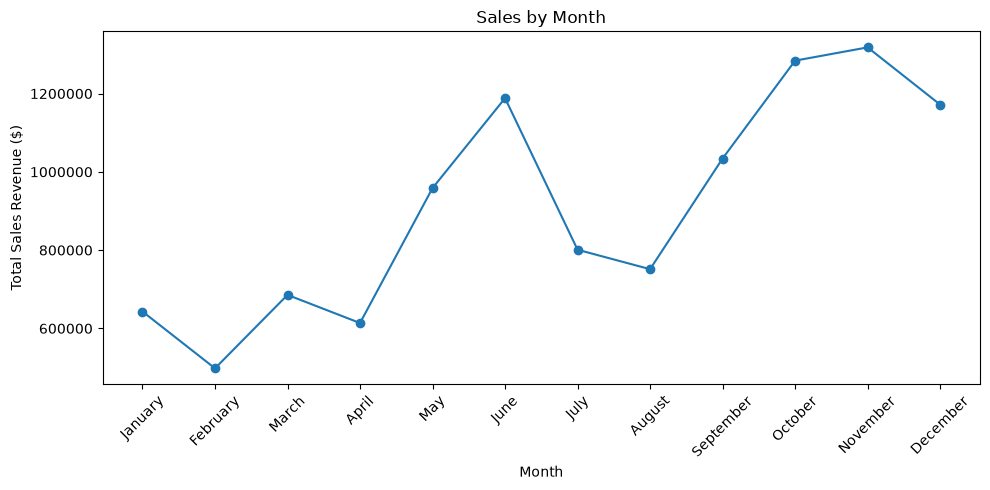

In [111]:
#Line chart
monthly_sales = df.groupby("Month")["TotalPrice"].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["Month"],monthly_sales["TotalPrice"],marker='o')
plt.ticklabel_format(style="plain", axis="y")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

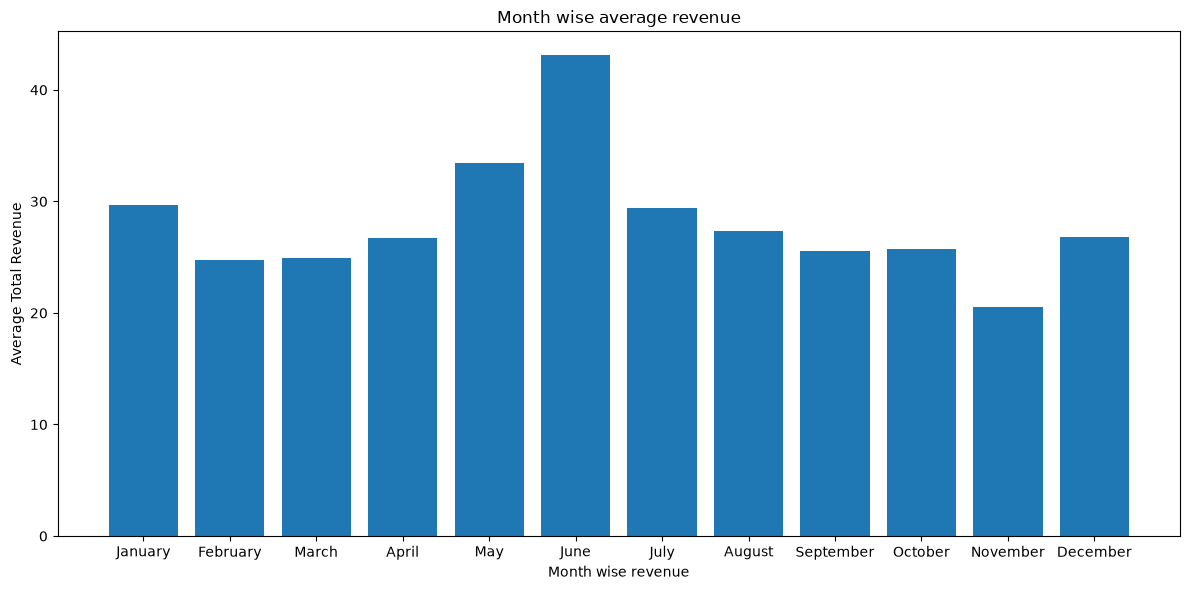

In [112]:
#Bar chart
month_spend_average = df.groupby("Month").agg(
                               TotalRevenue = ("TotalPrice","mean")
                              )
month_spend_average
plt.figure(figsize=(12,6))
plt.bar(month_spend_average.index,month_spend_average["TotalRevenue"])
plt.title("Month wise average revenue")
plt.xlabel("Month wise revenue")
plt.ylabel("Average Total Revenue")
plt.xticks(month_spend_average.index)
plt.tight_layout()
plt.show()

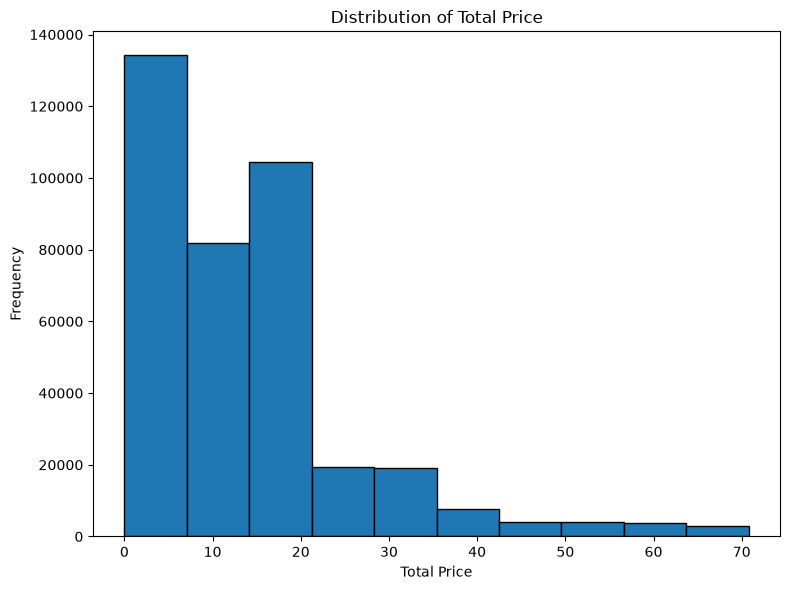

In [113]:
#Histogram
filtered_prices = df[(df["TotalPrice"] > 0) & (df["TotalPrice"] < df["TotalPrice"].quantile(0.95))]["TotalPrice"]
plt.figure(figsize=(8,6))
plt.hist(filtered_prices, edgecolor="black")
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


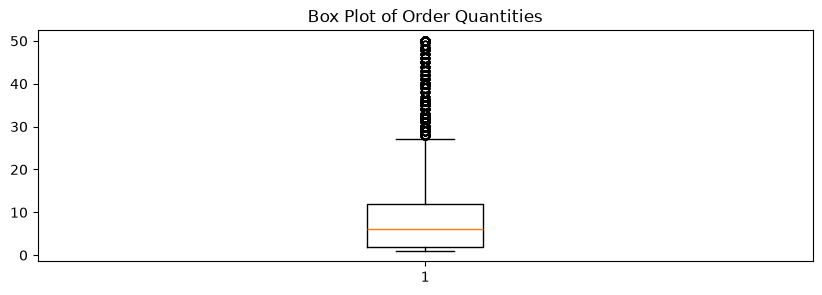

In [114]:
#Box plot
typical_orders = df[(df["Quantity"] > 0) & (df["Quantity"] <= 50)]["Quantity"]
plt.figure(figsize=(10,3))
plt.title("Box Plot of Order Quantities")
plt.boxplot(typical_orders)
plt.show()

###**Seaborn:**

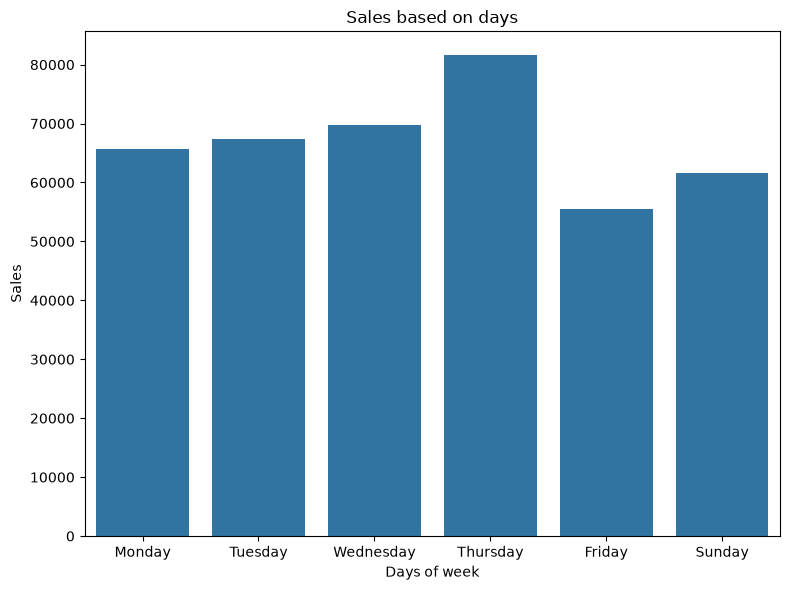

In [115]:
#Count plot
plt.figure(figsize=(8,6))
base_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_order = [day for day in base_order if day in df["DayName"].unique()]
sns.countplot(data=df,x="DayName",order=weekday_order)
plt.title("Sales based on days")
plt.xlabel("Days of week")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

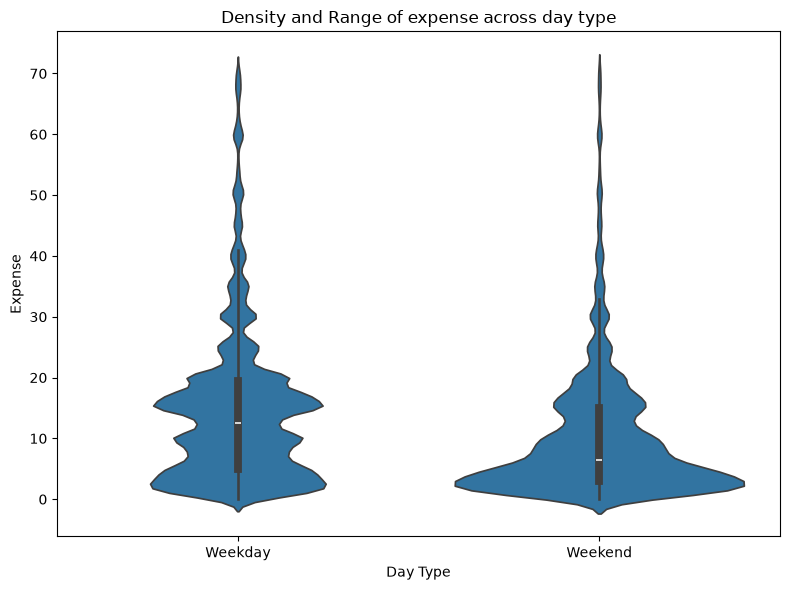

In [116]:
#Violin plot
plt.figure(figsize=(8,6))
filtered_df = df[df["TotalPrice"] < df["TotalPrice"].quantile(0.95)]
sns.violinplot(data=filtered_df,x="DayType",y="TotalPrice")
plt.title("Density and Range of expense across day type")
plt.xlabel("Day Type")
plt.ylabel("Expense")
plt.tight_layout()
plt.show()

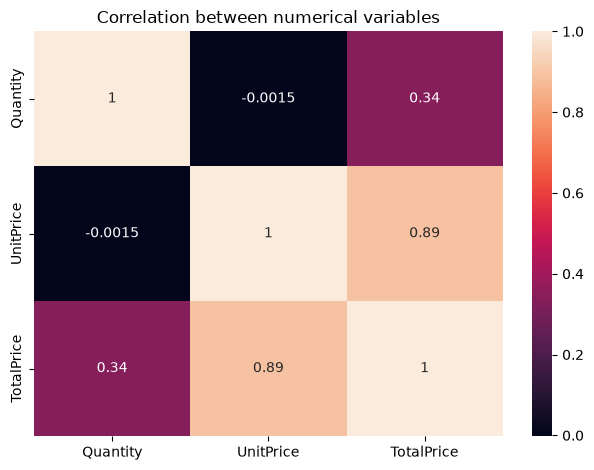

In [117]:
#Heatmap
corr_matrix = df[anlyse_columns].corr()
sns.heatmap(corr_matrix,annot = True)
plt.title("Correlation between numerical variables")
plt.tight_layout()
plt.show()

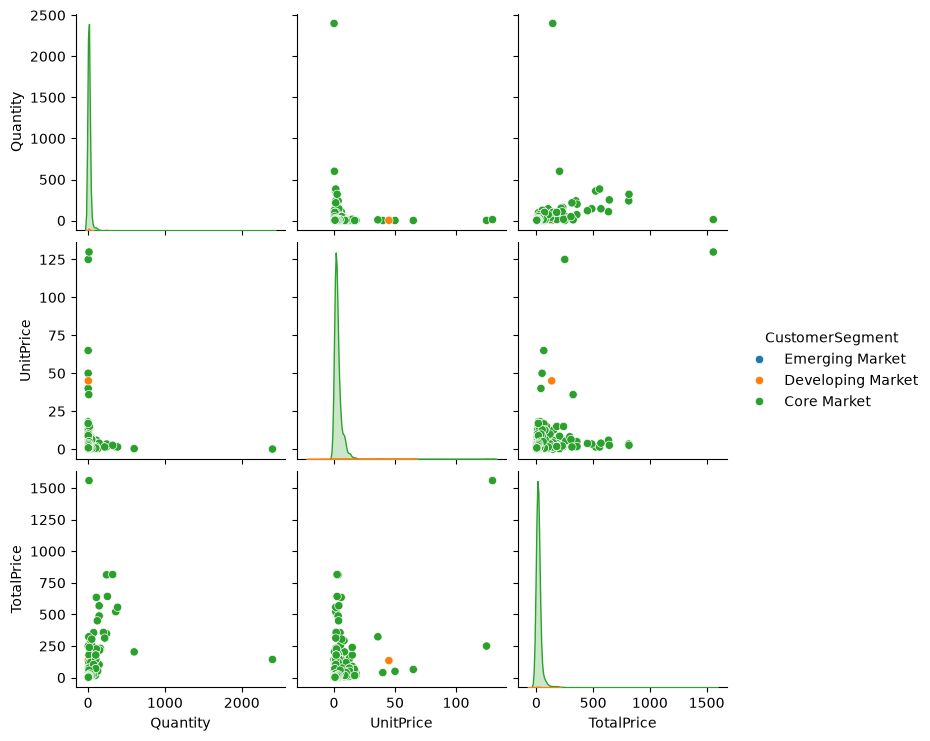

In [118]:
#Pair plot
#Pair plot based on customer segment
sampled_df = df[anlyse_columns + ["CustomerSegment"]].dropna().sample(
    n=min(2000, len(df)), random_state=42
)
sns.pairplot(data=sampled_df,hue="CustomerSegment")
plt.show()

###**Task 8 – Business Insights**

In [119]:
#Identify:"Top country"
top_countries = (
    df.groupby("Country").
    agg(TotalPrice = ("TotalPrice","sum")).
    sort_values(by="TotalPrice",ascending =  False).
    reset_index()
    )
top_countries['TotalPrice'] = top_countries['TotalPrice'].round(2)
print(f'Top Country by sales is: {top_countries["Country"].iloc[0]} with sales of ${top_countries["TotalPrice"].iloc[0]}')

Top Country by sales is: United Kingdom with sales of $8864442.46


In [120]:
#Identify:Best sales month
monthly_sales = df.groupby("Month")["TotalPrice"].sum().round(2)
print(f'The best sales month is: {monthly_sales.idxmax()} with sales of {monthly_sales.max()}')


The best sales month is: November with sales of 1318037.48


In [121]:
#Peak sales time
hourly_sales = df.groupby("Hour")["TotalPrice"].sum()
peak_hour = hourly_sales.idxmax()
print(f"The peak sales time is {peak_hour}:00 ({peak_hour % 12 or 12} {'PM' if peak_hour >= 12 else 'AM'})")

The peak sales time is 12:00 (12 PM)


In [122]:
#Analyze High-value customers  based on for how much value a customer has purchased
customer_spend = df.groupby("CustomerID")["TotalPrice"].sum().round(2)
customer_spend.nlargest(5)

CustomerID
15098.0    507615.90
18102.0    298283.02
14646.0    284896.52
16029.0    265421.76
17450.0    220512.03
Name: TotalPrice, dtype: float64

In [123]:
#Top products based on how many quantity is purchased
top_products = df.groupby("Description")["Quantity"].sum().round(2)
top_products.nlargest(5)

Description
PAPER CRAFT , LITTLE BIRDIE           81007
MEDIUM CERAMIC TOP STORAGE JAR        78036
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54379
JUMBO BAG RED RETROSPOT               46606
WHITE HANGING HEART T-LIGHT HOLDER    37210
Name: Quantity, dtype: int64